## Q1. Explain the concept of homogeneity and completeness in clustering evaluation. How are they calculated?
## Answer 

#### What Is Homogeneity?
- Definition: 
    - A clustering result is homogeneous if each cluster contains only data points from a single class.
- Goal: 
    - Avoid mixing different classes in the same cluster.
- Example: 
    - If cluster A contains only cats and cluster B only dogs, it’s highly homogeneous.
####
#### What Is Completeness?
- Definition: 
    - A clustering result is complete if all data points from a given class are assigned to the same cluster.
- Goal: 
    - Avoid splitting one class across multiple clusters.
- Example: 
    - If all cat images are grouped into one cluster, completeness is high.
####
### How to Calculate :

In [2]:
from sklearn.metrics import homogeneity_score, completeness_score

#### homogeneity = homogeneity_score(true_labels, predicted_labels)
#### completeness = completeness_score(true_labels, predicted_labels)

## 

## Q2. What is the V-measure in clustering evaluation? How is it related to homogeneity and completeness?
## Answer

- Definition: 
    - V-measure evaluates how well the clusters produced by an algorithm match the actual class labels.
- Range: 
    - 0 to 1 (higher is better).
- Goal: 
    - Achieve both high homogeneity (pure clusters) and high completeness (entire classes grouped together).

In [30]:
from sklearn.datasets import load_iris
dataset = load_iris()
X = dataset.data
y = dataset.target


In [12]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, init="k-means++")
predicted_labels = kmeans.fit_predict(X)

In [13]:
from sklearn.metrics import v_measure_score
v_score = v_measure_score(y, predicted_labels)

In [18]:
v_score ## It is the harmonic mean of these two scores, 
## providing a single value to assess how well clusters align with true class labels.

0.7419116631817836

In [19]:
homogeneity_score(y, predicted_labels)

0.7364192881252849

In [20]:
completeness_score(y, predicted_labels)

0.7474865805095324

## 

## Q3. How is the Silhouette Coefficient used to evaluate the quality of a clustering result? What is the range of its values?
## Answer 

#### range = -1 to 1

In [23]:
from sklearn.metrics import silhouette_score

In [26]:
silhouette_score(X, kmeans.labels_)

0.551191604619592

## 

## Q4. How is the Davies-Bouldin Index used to evaluate the quality of a clustering result? What is the range of its values?
## Answer 

#### DBI compares:
- Intra-cluster similarity: 
    - How close points are within the same cluster.
- Inter-cluster separation: 
    - How far apart clusters are from each other.
#### For each cluster, it calculates a similarity ratio with its most similar (closest) cluster. The final DBI is the average of these worst-case similarities across all clusters.

## 

#### Range (0 to 2+):
- 0 : Perfect Clustering
- lower : better clustering quality
- higher : poo clustering

## 

In [28]:
from sklearn.metrics import davies_bouldin_score
dbs_score = davies_bouldin_score(X, kmeans.labels_)

In [29]:
dbs_score

0.6660385791628493

## 

## Q5. Can a clustering result have a high homogeneity but low completeness? Explain with an example.
## Answer 

#### Clustering Result:
- Cluster A: 10 Cats
- Cluster B: 10 Cats
- Cluster C: 10 Dogs
- Cluster D: 10 Dogs
#### 
### Evaluation:
#### Homogeneity is high:
- Each cluster contains only one class (pure clusters).
#### Completeness is low:
- Cats are split between Cluster A and B.
- Dogs are split between Cluster C and D.

## 

## Q6. How can the V-measure be used to determine the optimal number of clusters in a clustering algorithm?
## Answer 

In [51]:
from sklearn.datasets import load_iris

In [61]:
dataset = load_iris()
X = dataset.data
y = dataset.target

In [62]:
v_scores =[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    X_new = kmeans.fit(X)
    v_score = v_measure_score(y, X_new.labels_)
    v_scores.append(v_score)

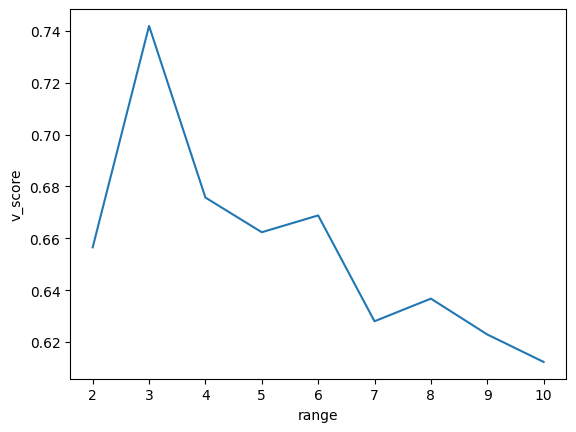

In [63]:
import matplotlib.pyplot as plt
plt.plot(range(2,11), v_scores)
plt.xticks(range(2,11))
plt.xlabel("range")
plt.ylabel("v_score")
plt.show()

In [44]:
v_scores

[0.0,
 0.6565191143081123,
 0.7581756800057784,
 0.7199262269988783,
 0.7700529490305067,
 0.6413361260617717,
 0.6965925609562132,
 0.5966202910425216,
 0.5902545653190304,
 0.6138115280755405]

## 

## Q7. What are some advantages and disadvantages of using the Silhouette Coefficient to evaluate a clustering result?
## Answer

#### Advantages of Silhouette Coefficient :
- Unsupervised: 
    - Doesn’t require true labels — ideal for real-world clustering tasks.
- Intuitive Interpretation:
    - Values range from -1 to 1.
    - +1 means well-clustered, 0 means on the boundary, < 0 means misclassified.
- Works Across Algorithms: 
    - Can be used with K-means, DBSCAN, hierarchical, and more.
- Point-Level Insight: 
    - Evaluates clustering quality per data point, allowing granular analysis.
- Helps Tune Parameters: 
    - Useful for selecting the optimal number of clusters (e.g., best k in K-means).

## 

#### Disadvantages of Silhouette Coefficient
- Sensitive to Cluster Shape:
    - Assumes convex clusters — struggles with non-spherical or density-based clusters (e.g., DBSCAN).
- Affected by Noise:
    - Noise points (especially in DBSCAN) can skew the average score.
- Computational Cost:
    - Requires pairwise distance calculations, which can be expensive for large datasets.
- May Mislead in High Dimensions:
    - Distance metrics become less meaningful in high-dimensional spaces (curse of dimensionality).

## 

## Q8. What are some limitations of the Davies-Bouldin Index as a clustering evaluation metric? How can they be overcome?
## Answer 

#### 1. DBI relies on centroid based distance and compactness.
    - it performs poorly with non convex or irregular shaped clusters.
#### 2. senstitive to scale :
    - Perform standard Scaling
#### 3. Affected by cluster size imbalance :
    - DBI penalize with high intra-cluster variance.
and etc...    

## 

## Q10. How can the Silhouette Coefficient be used to compare the quality of different clustering algorithms on the same dataset? What are some potential issues to watch out for?
## Answer 

#### Comparing Clustering Algorithms
- To compare algorithms (e.g., K-means vs DBSCAN vs Agglomerative), you can:
- Run each algorithm on the same dataset with appropriate parameters.
- Compute the Silhouette Coefficient for each point and take the mean across all points.
#### Compare the average scores:
- Higher average → better-defined clusters
- Use visualizations like silhouette plots to inspect cluster cohesion and separation

## Q10. How can the Silhouette Coefficient be used to compare the quality of different clustering algorithms on the same dataset? What are some potential issues to watch out for?
## Answer 

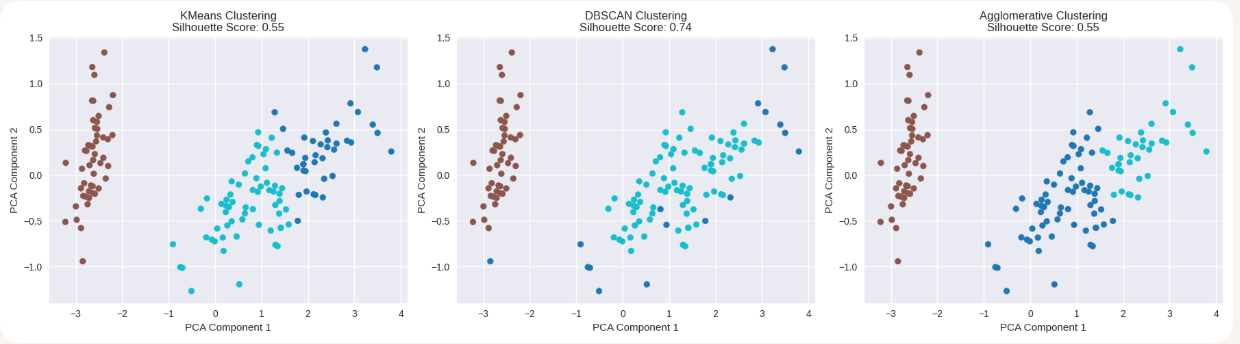

In [69]:
from IPython.display import Image
Image(filename='Screenshot 2025-10-31 005739.png')  # Replace with your image path

#### We used the classic Iris dataset (150 samples, 4 features) and reduced it to 2D using PCA for visualization. Each algorithm was applied with these parameters:
- KMeans: n_clusters=3
- DBSCAN: eps=0.5, min_samples=5
- Agglomerative Clustering: n_clusters=3

- KMeans--------------------0.55
- DBSCAN--------------------0.74
- Agglomerative--------------------	0.55

#### Interpretation :
- DBSCAN outperformed others by identifying dense regions and ignoring noise.
- KMeans and Agglomerative produced similar partitions, but may struggle with overlapping or non-spherical clusters.
- Silhouette Score helped quantify how well-separated and compact the clusters are.

## 

## Q11. How does the Davies-Bouldin Index measure the separation and compactness of clusters? What are some assumptions it makes about the data and the clusters?
## Answer

#### Assumptions and Limitations :
- Centroid-Based Clusters
    - DBI assumes each cluster has a well-defined centroid.
    - Works best with algorithms like KMeans or Agglomerative Clustering using average linkage.
- Convex and Isotropic Clusters
    - Assumes clusters are roughly spherical and similar in size.
    - Struggles with non-convex or density-based clusters (e.g., DBSCAN).
- Distance Metric Sensitivity
    - Relies on the Euclidean distance by default.
    - Results can vary significantly with different distance metrics.
- Equal Importance of Clusters
    - Treats all clusters equally, regardless of size or density.
    - May undervalue small but meaningful clusters.

#### When to Use DBI :
- Comparing clustering results with the same number of clusters
- Evaluating KMeans or hierarchical clustering
- As a complement to other metrics like Silhouette Score or Calinski-Harabasz Index

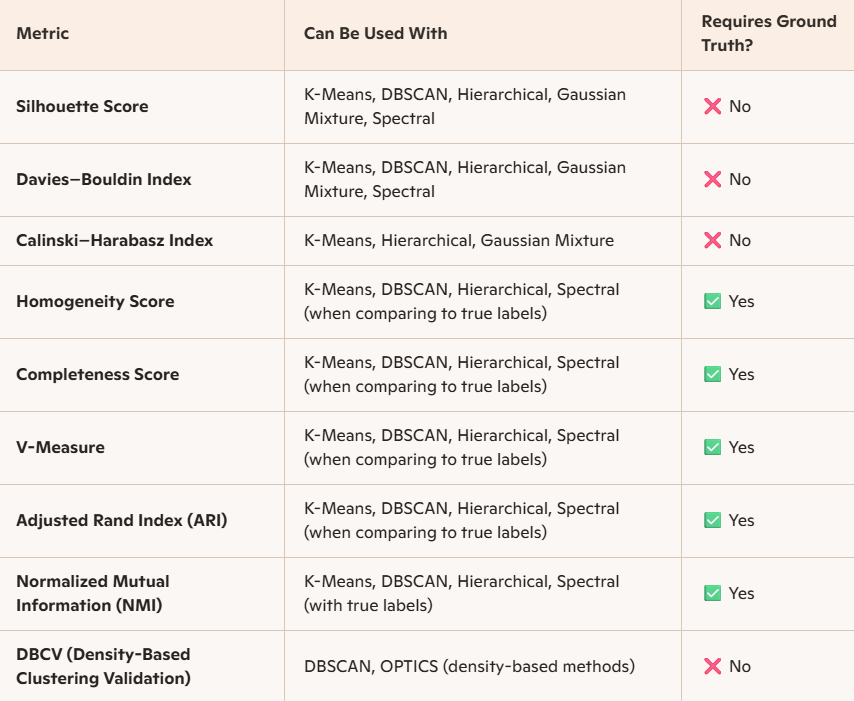

In [65]:
from IPython.display import Image
Image(filename='Screenshot 2025-10-31 000153.png')  # Replace with your image path